# Imports

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_recall_curve
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV, cross_validate, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder, OneHotEncoder, TargetEncoder, LabelEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
#from utils_modeling import (run_gridsearch, DataCleaner)
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.base import clone
from utils_modeling import (DataCleaner, OutlierClipper, CategoricalFeatureSelector, NumericalFeatureSelector)
import pickle
SEED = 23 

pd.options.display.float_format = None
pd.options.display.max_columns = None

In [2]:
import os
if os.getcwd() != 'c:\\Users\\dinis\\OneDrive\\Ambiente de Trabalho\\Faculdade - MGI-BI\\1º ano\\2º Semestre\\Data Mining II\\Project\\DM2_Project':
    %cd ..
train = pd.read_csv('Files/donors_train.csv')
test = pd.read_csv('Files/donors_test.csv')

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project


# Other/Extra

## Modeling

### NaN

In [3]:
X = train.drop(['TARGET_B'], axis=1)
y = train['TARGET_B']

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=SEED)

## Classes

In [5]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.feature_names_in_ = None
        self.enginereed_features_ = None

    def fit(self, X, y=None):
        self.feature_names_in_ = np.array(X.columns, dtype=object)
        return self

    def transform(self, X):
        X = X.copy()
        # Creating the engineered variables
        X['LIFETIME_AVG_GIFT_AMT'] = X['LIFETIME_GIFT_AMOUNT'] / X['LIFETIME_GIFT_COUNT']
        X['LIFETIME_GIFT_AMT_RANGE'] = X['LIFETIME_MAX_GIFT_AMT'] - X['LIFETIME_MIN_GIFT_AMT']
        X['AVG_TO_LAST_GIFT_RATIO'] = X['LIFETIME_AVG_GIFT_AMT'] / X['LAST_GIFT_AMT'].replace(0, np.nan)
        X['DONOR_LIFESPAN_MONTHS'] = X['MONTHS_SINCE_FIRST_GIFT'] - X['MONTHS_SINCE_LAST_GIFT']
        X['GIFTS_PER_MONTH_LIFESPAN'] = X['LIFETIME_GIFT_COUNT'] / X['DONOR_LIFESPAN_MONTHS'].replace(0, np.nan)
        X['GIFT_TO_HOUSEHOLD_INCOME_RATIO'] = X['LIFETIME_AVG_GIFT_AMT'] / X['MEDIAN_HOUSEHOLD_INCOME'].replace(0, np.nan)
        self.enginereed_features_ = set(X.columns) - set(self.feature_names_in_)
        return X
        
    def get_feature_names_out(self, input_features=None):
        return np.append(self.feature_names_in_, list(self.engineered_features_))

# Pipeline

## Things

In [6]:
categorical_admissible_values = {
    "DONOR_GENDER": ["M", "F", "U"],
    "PEP_STAR": [0, 1],
    "RECENCY_STATUS_96NK": ["S", "A", "E", "F", "N", "L"],
    "RECENT_STAR_STATUS": [0, 1],
    "SES": np.arange(1, 6),
    "URBANICITY": ["S", "T", "U", "R", "C"],
    "INCOME_GROUP" : np.arange(1, 8),
    "WEALTH_RATING" : np.arange(0, 10)
}

In [7]:
restricted_profile = {
    'DONOR_AGE': {'lower': 18, 'upper': 100},
    'MEDIAN_HOME_VALUE': {'lower': 4000, 'upper': None},
    'MEDIAN_HOUSEHOLD_INCOME': {'lower': 800, 'upper': None},
    'PCT_OWNER_OCCUPIED': {'lower': 20, 'upper': None},
    'PER_CAPITA_INCOME': {'lower': 3500, 'upper': None},
    'PCT_ATTRIBUTE1': {'lower': None, 'upper': None},  # Noted as '?'
    'PCT_ATTRIBUTE2': {'lower': 10, 'upper': 60},
    'PCT_ATTRIBUTE3': {'lower': 70, 'upper': None},
    'PCT_ATTRIBUTE4': {'lower': 80, 'upper': None},
    'RECENT_RESPONSE_PROP': {'lower': 0.55, 'upper': None},
    'RECENT_AVG_GIFT_AMT': {'lower': 70, 'upper': None},
    'RECENT_CARD_RESPONSE_PROP': {'lower': 0.8, 'upper': None},
    'RECENT_AVG_CARD_GIFT_AMT': {'lower': 70, 'upper': None},
    'RECENT_RESPONSE_COUNT': {'lower': 8, 'upper': None},
    'RECENT_CARD_RESPONSE_COUNT': {'lower': 4, 'upper': None},
    'MONTHS_SINCE_LAST_PROM_RESP': {'lower': None, 'upper': 30},  # Kept as requested, though bounds overlap
    'LIFETIME_PROM': {'lower': 125, 'upper': None},
    'LIFETIME_GIFT_AMOUNT': {'lower': 400, 'upper': None},
    'LIFETIME_GIFT_COUNT': {'lower': 30, 'upper': None},
    'LIFETIME_MAX_GIFT_AMT': {'lower': 50, 'upper': None},
    'LIFETIME_MIN_GIFT_AMT': {'lower': 30, 'upper': None},
    'LAST_GIFT_AMT': {'lower': 50, 'upper': None},
    'CARD_PROM_12': {'lower': 3, 'upper': 7},
    'NUMBER_PROM_12': {'lower': 8, 'upper': 20},
    'MONTHS_SINCE_LAST_GIFT': {'lower': 10, 'upper': None},
    'MONTHS_SINCE_FIRST_GIFT': {'lower': None, 'upper': 200},
    'FILE_CARD_GIFT': {'lower': 20, 'upper': None}
}

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import percentileofscore


def calculate_profile_quantiles(
    df: pd.DataFrame, restricted_profile: dict
) -> dict:
    """Calculates the decimal quantiles (0.0 to 1.0) for the lower and upper bounds

    of a restricted profile, making them ready to pass into df.quantile().
    """
    quantile_profile = {}

    for column, bounds in restricted_profile.items():
        if column not in df.columns:
            quantile_profile[column] = {"lower": None, "upper": None}
            continue

        clean_data = df[column].dropna()

        if clean_data.empty:
            quantile_profile[column] = {"lower": None, "upper": None}
            continue

        lower_val = bounds.get("lower")
        upper_val = bounds.get("upper")

        # Calculate lower percentile and convert 0-100 score to 0.0-1.0 decimal
        if lower_val is not None:
            lower_pct = percentileofscore(clean_data, lower_val, kind="weak")
            lower_q = round(lower_pct / 100.0, 4)  # 4 decimals for precision
        else:
            lower_q = None

        # Calculate upper percentile and convert to 0.0-1.0 decimal
        if upper_val is not None:
            upper_pct = percentileofscore(clean_data, upper_val, kind="weak")
            upper_q = round(upper_pct / 100.0, 4)
        else:
            upper_q = None

        quantile_profile[column] = {"lower": lower_q, "upper": upper_q}

    return quantile_profile

In [15]:
calculate_profile_quantiles(train, relaxed_profile)

{'DONOR_AGE': {'lower': np.float64(0.0203), 'upper': np.float64(0.9931)},
 'MEDIAN_HOME_VALUE': {'lower': np.float64(0.9411), 'upper': None},
 'MEDIAN_HOUSEHOLD_INCOME': {'lower': np.float64(0.9929), 'upper': None},
 'PCT_OWNER_OCCUPIED': {'lower': np.float64(0.0113), 'upper': None},
 'PER_CAPITA_INCOME': {'lower': np.float64(0.019), 'upper': None},
 'PCT_ATTRIBUTE1': {'lower': None, 'upper': None},
 'PCT_ATTRIBUTE2': {'lower': None, 'upper': np.float64(0.9983)},
 'PCT_ATTRIBUTE3': {'lower': np.float64(0.9978), 'upper': None},
 'PCT_ATTRIBUTE4': {'lower': np.float64(1.0), 'upper': None},
 'RECENT_RESPONSE_PROP': {'lower': np.float64(0.9976), 'upper': None},
 'RECENT_AVG_GIFT_AMT': {'lower': np.float64(0.9797), 'upper': None},
 'RECENT_CARD_RESPONSE_PROP': {'lower': None, 'upper': None},
 'RECENT_AVG_CARD_GIFT_AMT': {'lower': np.float64(0.9887), 'upper': None},
 'RECENT_RESPONSE_COUNT': {'lower': np.float64(0.0179), 'upper': None},
 'RECENT_CARD_RESPONSE_COUNT': {'lower': np.float64(0.9

In [8]:
relaxed_profile = {
    'DONOR_AGE': {'lower': 18, 'upper': 100},
    'MEDIAN_HOME_VALUE': {'lower': 3000, 'upper': None},
    'MEDIAN_HOUSEHOLD_INCOME': {'lower': 1000, 'upper': None},
    'PCT_OWNER_OCCUPIED': {'lower': 0, 'upper': None},
    'PER_CAPITA_INCOME': {'lower': 5000, 'upper': None},
    'PCT_ATTRIBUTE1': {'lower': None, 'upper': None},
    'PCT_ATTRIBUTE2': {'lower': None, 'upper': 70},  # Kept as requested, though bounds overlap
    'PCT_ATTRIBUTE3': {'lower': 80, 'upper': None},
    'PCT_ATTRIBUTE4': {'lower': 100, 'upper': None},
    'RECENT_RESPONSE_PROP': {'lower': 0.70, 'upper': None},
    'RECENT_AVG_GIFT_AMT': {'lower': 45, 'upper': None},
    'RECENT_CARD_RESPONSE_PROP': {'lower': None, 'upper': None},  # Noted as "didn't catch it"
    'RECENT_AVG_CARD_GIFT_AMT': {'lower': 45, 'upper': None},
    'RECENT_RESPONSE_COUNT': {'lower': 0, 'upper': None},
    'RECENT_CARD_RESPONSE_COUNT': {'lower': 6, 'upper': None},
    'MONTHS_SINCE_LAST_PROM_RESP': {'lower': 0, 'upper': 100},
    'LIFETIME_PROM': {'lower': 140, 'upper': None},
    'LIFETIME_GIFT_AMOUNT': {'lower': 750, 'upper': None},
    'LIFETIME_GIFT_COUNT': {'lower': 45, 'upper': None},
    'LIFETIME_MAX_GIFT_AMT': {'lower': 70, 'upper': None},
    'LIFETIME_MIN_GIFT_AMT': {'lower': 40, 'upper': None},
    'LAST_GIFT_AMT': {'lower': 80, 'upper': None},
    'CARD_PROM_12': {'lower': None, 'upper': 10},  # No lower limit
    'NUMBER_PROM_12': {'lower': None, 'upper': 30},  # Kept as requested, though bounds overlap
    'MONTHS_SINCE_LAST_GIFT': {'lower': None, 'upper': None},
    'MONTHS_SINCE_FIRST_GIFT': {'lower': None, 'upper': None},
    'FILE_CARD_GIFT': {'lower': None, 'upper': None}  # No limit
}

HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=500,
    max_depth=4,
    min_samples_leaf=100,
    l2_regularization=10.0,
    class_weight='balanced',
    random_state=SEED
)

In [11]:
X

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,3.0,33.0,M,0.00000,1.0,H,5.0,20.0000,9.0,35.0,2.0,20.0,15.0,21.0,566.0,315.0,182.037132,18.0,18.0,10.0,0.0,52.0,17.0,25.0,92.0,0.0,12827.0,A,0.00,17.50,NaN,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,2.0,NaN,F,1.00000,1.0,U,NaN,15.0000,6.0,15.0,1.0,15.0,15.0,15.0,318.0,148.0,24.000000,24.0,24.0,7.0,0.0,31.0,31.0,39.0,73.0,0.0,7787.0,N,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,2.0,NaN,F,7.00000,3.0,H,4.0,10.0000,17.0,79.0,11.0,12.0,5.0,40.0,1669.0,373.0,129.000000,15.0,15.0,8.0,0.0,26.0,39.0,38.0,84.0,1.0,13965.0,S,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,NaN,61.0,M,13.00000,1.0,H,6.0,11.0000,28.0,80.0,17.0,11.0,3.0,75.0,1464.0,488.0,130.000000,16.0,16.0,13.0,0.0,48.0,30.0,44.0,84.0,1.0,24123.0,A,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,0.0,75.0,M,3.00000,4.0,H,3.0,7.0000,9.0,27.0,5.0,7.0,5.0,22.0,936.0,249.0,24.000000,17.0,17.0,13.0,0.0,52.0,NaN,66.0,90.0,1.0,15008.0,N,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.0,84.0,M,6.00000,1.0,H,6.0,10.0000,32.0,135.0,12.0,NaN,5.0,69.0,558.0,285.0,97.000000,19.0,19.0,12.0,0.0,38.0,26.0,76.0,82.0,1.0,14603.0,A,10.00,NaN,1.0,0.100,2.0,0.095,6.0,2,C,3.0
13556,7550,7.0,4.0,86.0,F,16.00000,3.0,H,2.0,10.0000,33.0,185.0,30.0,15.0,3.0,81.0,1116.0,274.0,130.000000,17.0,17.0,16.0,0.0,42.0,40.0,30.0,36.0,1.0,21881.0,S,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
13557,115215,6.0,3.0,NaN,M,2.00000,3.0,U,1.0,10.0000,12.0,41.0,NaN,10.0,5.0,29.0,421.0,169.0,34.000000,17.0,17.0,12.0,1.0,23.0,21.0,48.0,32.0,0.0,6459.0,A,8.50,9.00,2.0,0.250,4.0,0.235,0.0,2,T,NaN
13558,88067,6.0,3.0,NaN,M,-10.09857,2.0,U,NaN,-21.8336,8.0,20.0,2.0,15.0,5.0,17.0,4153.0,891.0,21.000000,17.0,17.0,12.0,0.0,22.0,24.0,28.0,97.0,0.0,31378.0,N,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,NaN,NaN


In [12]:
FeatureEngineer().fit_transform(X)

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,LIFETIME_AVG_GIFT_AMT,LIFETIME_GIFT_AMT_RANGE,AVG_TO_LAST_GIFT_RATIO,DONOR_LIFESPAN_MONTHS,GIFTS_PER_MONTH_LIFESPAN,GIFT_TO_HOUSEHOLD_INCOME_RATIO
0,61745,4.0,3.0,33.0,M,0.00000,1.0,H,5.0,20.0000,9.0,35.0,2.0,20.0,15.0,21.0,566.0,315.0,182.037132,18.0,18.0,10.0,0.0,52.0,17.0,25.0,92.0,0.0,12827.0,A,0.00,17.50,NaN,0.000,2.0,0.154,0.0,2,T,NaN,17.500000,5.0,0.875000,164.037132,0.012192,0.055556
1,112703,3.0,2.0,NaN,F,1.00000,1.0,U,NaN,15.0000,6.0,15.0,1.0,15.0,15.0,15.0,318.0,148.0,24.000000,24.0,24.0,7.0,0.0,31.0,31.0,39.0,73.0,0.0,7787.0,N,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN,15.000000,0.0,1.000000,0.000000,NaN,0.101351
2,166437,4.0,2.0,NaN,F,7.00000,3.0,H,4.0,10.0000,17.0,79.0,11.0,12.0,5.0,40.0,1669.0,373.0,129.000000,15.0,15.0,8.0,0.0,26.0,39.0,38.0,84.0,1.0,13965.0,S,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN,7.181818,7.0,0.718182,114.000000,0.096491,0.019254
3,170621,4.0,NaN,61.0,M,13.00000,1.0,H,6.0,11.0000,28.0,80.0,17.0,11.0,3.0,75.0,1464.0,488.0,130.000000,16.0,16.0,13.0,0.0,48.0,30.0,44.0,84.0,1.0,24123.0,A,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN,4.705882,8.0,0.427807,114.000000,0.149123,0.009643
4,44428,6.0,0.0,75.0,M,3.00000,4.0,H,3.0,7.0000,9.0,27.0,5.0,7.0,5.0,22.0,936.0,249.0,24.000000,17.0,17.0,13.0,0.0,52.0,NaN,66.0,90.0,1.0,15008.0,N,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN,5.400000,2.0,0.771429,7.000000,0.714286,0.021687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.0,84.0,M,6.00000,1.0,H,6.0,10.0000,32.0,135.0,12.0,NaN,5.0,69.0,558.0,285.0,97.000000,19.0,19.0,12.0,0.0,38.0,26.0,76.0,82.0,1.0,14603.0,A,10.00,NaN,1.0,0.100,2.0,0.095,6.0,2,C,3.0,11.250000,NaN,1.125000,78.000000,0.153846,0.039474
13556,7550,7.0,4.0,86.0,F,16.00000,3.0,H,2.0,10.0000,33.0,185.0,30.0,15.0,3.0,81.0,1116.0,274.0,130.000000,17.0,17.0,16.0,0.0,42.0,40.0,30.0,36.0,1.0,21881.0,S,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0,6.166667,12.0,0.616667,113.000000,0.265487,0.022506
13557,115215,6.0,3.0,NaN,M,2.00000,3.0,U,1.0,10.0000,12.0,41.0,NaN,10.0,5.0,29.0,421.0,169.0,34.000000,17.0,17.0,12.0,1.0,23.0,21.0,48.0,32.0,0.0,6459.0,A,8.50,9.00,2.0,0.250,4.0,0.235,0.0,2,T,NaN,NaN,5.0,NaN,17.000000,NaN,NaN
13558,88067,6.0,3.0,NaN,M,-10.09857,2.0,U,NaN,-21.8336,8.0,20.0,2.0,15.0,5.0,17.0,4153.0,891.0,21.000000,17.0,17.0,12.0,0.0,22.0,24.0,28.0,97.0,0.0,31378.0,N,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,NaN,NaN,10.000000,10.0,-0.458010,4.000000,0.500000,0.011223


## Actual Pipeline

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestRegressor



# Categorical Feature Sub-Pipeline
# This is the part that handles the categorical columns, performing
# mode imputation, feature selection using our custom CategoricalFeatureSelector
# and finally one-hot encoding the features.
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('feature_selection',  CategoricalFeatureSelector()),
    # 3. Your specialized encoding (OneHot/Target) now receives imputed integers
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

# Numerical Feature Sub-Pipeline
# Here we take care of our numerical features, starting with outlier clipping and feature
# creation using our custom transformer, then scaling data, so that it can then 
# be imputed and numerical feature selection can be performed
num_pipe = Pipeline([
    ('clipper', OutlierClipper(iqr_multiplier=2)),
    ('feature_engineer', FeatureEngineer()),
    ('scaler', RobustScaler()),
    ('imputer', KNNImputer()),
    ('feature_selection', NumericalFeatureSelector(random_state=SEED))
])

# Here we use a ColumnTransformer with column selectors to perform the split
# between numerical and categorical data, so that each subset can be directed
# to the appropriate sub-pipeline
preprocessor = ColumnTransformer([
    ('cat_section', cat_pipe, make_column_selector(dtype_exclude=[np.number])),
    ('num_section', num_pipe, make_column_selector(dtype_include=[np.number])),
],
verbose_feature_names_out=False)
#  


base_lr = LogisticRegression(class_weight='balanced', C=1.1, solver='liblinear', random_state=SEED)
 
# Final Pipeline
pipe = Pipeline([
    ('cleaner', DataCleaner(categorical_cols_values=categorical_admissible_values)),
    ('preprocessing', preprocessor),
    ('model', TunedThresholdClassifierCV(base_lr,
                                         n_jobs=-1,
                                         scoring='f1',
                                         random_state=SEED
                                         )) 
])

# We use the set_output to pandas so that intermediate transformers can use column
# names, since some of the default scikit-learn transformers by default return 
# Numpy arrays, which obviously don't have column names.
pipe.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,categorical_cols_values,"{'DONOR_GENDER': ['M', 'F', ...], 'INCOME_GROUP': array([1, 2, 3, 4, 5, 6, 7]), 'PEP_STAR': [0, 1], 'RECENCY_STATUS_96NK': ['S', 'A', ...], ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that

In [ ]:
pipe.fit(X_train, y_train)

c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\pandas\core\nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\dinis\anacon

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,categorical_cols_values,"{'DONOR_GENDER': ['M', 'F', ...], 'INCOME_GROUP': array([1, 2, 3, 4, 5, 6, 7]), 'PEP_STAR': [0, 1], 'RECENCY_STATUS_96NK': ['S', 'A', ...], ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that

In [ ]:
pred_train = pipe.predict(X_train)

In [ ]:
pred_val = pipe.predict(X_val)

In [ ]:
f1_score(y_train, pred_train)

0.42137950503434646

In [ ]:
f1_score(y_val, pred_val)

0.43318318318318316

In [ ]:
pipe['model'].best_threshold_

np.float64(0.4201681054034526)

Text(0.5, 1.0, 'Confusion Matrix')

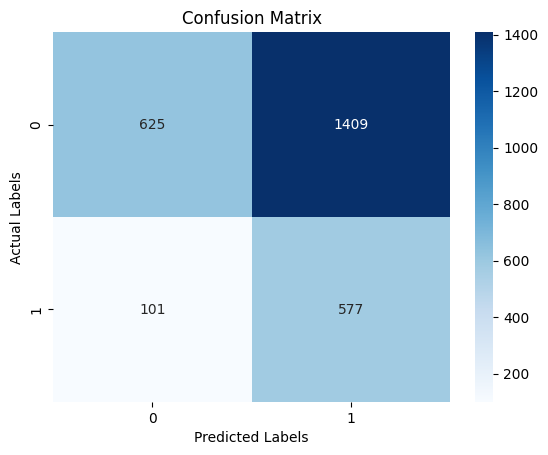

In [ ]:
sns.heatmap(confusion_matrix(y_val, pred_val), fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_val),
                    yticklabels=np.unique(y_val), annot=True)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

In [ ]:
print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.86      0.31      0.45      2034
           1       0.29      0.85      0.43       678

    accuracy                           0.44      2712
   macro avg       0.58      0.58      0.44      2712
weighted avg       0.72      0.44      0.45      2712



pipe = clone(pipe)
pipe.fit(X, y)

pd.DataFrame(pipe.predict(test)).value_counts()

%cd ..

%ls

pd.DataFrame(pipe.predict(test), index=test['CONTROL_NUMBER'], columns=['TARGET_B']).to_csv('Datasets/Submissions/DM2DT_Group12_Version16.csv')

## CrossValidation

In [17]:
skf_test = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [26]:
pipe=clone(pipe)

In [27]:
cv_results = cross_validate(pipe, X, y, cv=skf_test,
                                        return_train_score=True,
                                        scoring=['f1', 'accuracy',
                                    'precision', 'recall'], n_jobs=-1, verbose=3)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.9min remaining:  2.9min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.0min finished


In [28]:
pd.DataFrame(cv_results).mean()

fit_time           87.152195
score_time          3.837637
test_f1             0.414680
train_f1            0.422212
test_accuracy       0.455015
train_accuracy      0.463735
test_precision      0.284121
train_precision     0.289635
test_recall         0.771976
train_recall        0.783776
dtype: float64

# Parameter Search

In [14]:
param_grid = {'preprocessing__num_section__feature_engineer' : [None, FeatureEngineer()]}

In [18]:
from tqdm.auto import tqdm
def run_parameter_search(grid: dict,
                         cv: any,
                         X: any,
                         y: any, 
                         model: any,
                         metrics: list,
                         results_file_dir: str = None,
                         model_file_dir: str = None,
                         refit: bool = True) -> pd.DataFrame:
    """Performs a manual parameter search with cross-validation.

    This allows the inclusion of a TQDM progress bar to track hyperparameter 
    tuning and evaluation progress.

    Args:
        grid (dict): Dictionary with parameter names as keys and lists of
            settings to try as values.
        cv (any): Determines the cross-validation splitting strategy (e.g., an
            integer or a scikit-learn CV splitter).
        X (any): The training input samples.
        y (any): The target values.
        model (any): The estimator object to use to fit the data.
        metrics (list): The list of metric functions or names to be used for
            evaluating the model. The first metric is the one used to sort
            results at the end.
        results_file_dir (str, optional): Directory path where the search 
            results DataFrame will be saved. Defaults to None.
        model_file_dir (str, optional): Directory path where the best fitted 
            model. Defaults to None.
        refit (bool, optional): If True, refits the best estimator using the 
            entire dataset. Defaults to True.

    Returns:
        pd.DataFrame: A DataFrame containing the parameter combinations, 
        mean/std scores for training and validation splits, and execution status.
    """
    # Build a ParameterGrid based on the parameters to test
    params = ParameterGrid(grid)
    # Initializing the results and the primary metric, which will
    # be the one used to sort runs at the end.
    results = []
    primary_metric = metrics[0]
    for param in tqdm(params, desc="Tuning Hyperparameters"):
        # Initializing the run record with the full dictionary of parameters
        # as well as unpacking that dictionary to create a column for each
        # parameter as that may be useful.
        run_record = {'params_config': param.copy(),
                      **param}
        # We use the try/except block to ensure that if there's any issue with one
        # parameter combination (certain parameter settings are incompatible) 
        # we still test all valid ones
        try:
            # Cloning the input model, applying the paramters
            # and the pandas output mode
            current_model = clone(model)
            current_model.set_params(**param)
            current_model.set_output(transform="pandas")
            # Running the cross-validation and processing
            # all of the relevant metrics (scores and fit-time)
            crossval_results = cross_validate(current_model, X, y, cv=cv,
                                        return_train_score=True,
                                        scoring=metrics, n_jobs=-1, error_score='raise')         
            run_record['mean_fit_time'] = np.mean(crossval_results['fit_time'])
            for metric in metrics:
                run_record[f'mean_val_{metric}'] = np.mean(crossval_results[f'test_{metric}'])
                run_record[f'std_val_{metric}'] = np.std(crossval_results[f'test_{metric}'])
                run_record[f'mean_train_{metric}'] = np.mean(crossval_results[f'train_{metric}'])
                run_record[f'std_train_{metric}'] = np.std(crossval_results[f'train_{metric}'])
            # Classifying the combination as successfull
            run_record['status'] = 'Success'
        except Exception as e:
            # If the parameter combination fails put missing values in all 
            # of the metric columns
            run_record['mean_fit_time'] = np.nan
            for metric in metrics:
                run_record[f'mean_val_{metric}'] = np.nan
                run_record[f'std_val_{metric}'] = np.nan
                run_record[f'mean_train_{metric}'] = np.nan
                run_record[f'std_train_{metric}'] = np.nan
            # Classifying the combination as failed
            run_record['status'] = f'Failed: {str(e)}'
        # Appending the run_record to the results
        results.append(run_record)
        # Creating the dataframe and sorting by the primary metric
        df_result = pd.DataFrame(results).sort_values(f'mean_val_{primary_metric}', ascending=False)
    # Checking whether there is a directory to export results
    # and using pickle to export it if there is
    if results_file_dir is not None:
        df_result.to_pickle(results_file_dir)
    # Checking whether the best model is to be refitted on the full data
    # and grabbing the best parameter combination, applying it and 
    # fitting the model if it is to be refitted.
    if refit:
        best_model = clone(model)
        best_model.set_params(**df_result.iloc[0]['params_config'])
        best_model.set_output(transform="pandas")
        best_model_fitted = best_model.fit(X, y)
        # Checking whether there is a directory to export the model
        # and using pickle to export it if there is
        if model_file_dir is not None:
            best_model_fitted.to_pickle(model_file_dir)
        return df_result, best_model_fitted
    else:    
        return df_result

In [19]:
result_df = run_parameter_search(grid=param_grid, cv=skf_test, X=X, y=y, model=pipe, metrics=['f1',
                                    'precision', 'recall'], refit=False)
result_df

Tuning Hyperparameters:   0%|          | 0/2 [00:00<?, ?it/s]

,params_config,preprocessing__num_section__feature_engineer,mean_fit_time,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,mean_val_precision,std_val_precision,mean_train_precision,std_train_precision,mean_val_recall,std_val_recall,mean_train_recall,std_train_recall,status
0,{'preprocessing__num_section__feature_engineer...,None,39.667389,0.415299,0.004900,0.422007,0.002039,0.284013,0.007990,0.288977,0.006806,0.775516,0.039083,0.785988,0.046281,Success
1,{'preprocessing__num_section__feature_engineer...,FeatureEngineer(),84.146405,0.414680,0.003081,0.422212,0.001163,0.284121,0.008297,0.289635,0.007594,0.771976,0.048665,0.783776,0.053140,Success


In [41]:
result_df['params_config']

0    {'preprocessing__num_section__feature_engineer...
1    {'preprocessing__num_section__feature_engineer...
Name: params_config, dtype: object

In [ ]:
best_model.predict(test)

array([0, 1, 1, ..., 1, 1, 1], shape=(5812,))

In [857]:
pipe.fit(X, y)

c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\L

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [858]:
%ls

 Volume in drive C is Local Disk
 Volume Serial Number is 0008-FF61

 Directory of c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1� ano\2� Semestre\Data Mining II\Project

18/05/2026  14:48    <DIR>          .
11/03/2026  15:11    <DIR>          ..
29/03/2026  18:21    <DIR>          __pycache__
18/05/2026  14:48    <DIR>          DM2_Project
               0 File(s)              0 bytes
               4 Dir(s)  724�965�117�952 bytes free


In [859]:
%cd DM2_Project/

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project


In [860]:
pd.DataFrame(pipe.predict(test), index=test['CONTROL_NUMBER'], columns=['TARGET_B']).to_csv('Datasets/Submissions/DM2DT_Group12_Version17.csv')

# TRAIN

In [33]:
pipe=clone(pipe)
prepro = pipe[:-1]
X_train_t = prepro.fit_transform(X_train, y_train)
X_val_t = prepro.transform(X_val)

c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\pandas\core\nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'p

In [34]:
X_train_t

,RECENCY_STATUS_96NK_E,RECENCY_STATUS_96NK_F,RECENCY_STATUS_96NK_L,RECENCY_STATUS_96NK_N,RECENCY_STATUS_96NK_S,CARD_PROM_12,CHILDREN,DONOR_AGE,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,MEDIAN_HOME_VALUE,MONTHS_SINCE_LAST_GIFT,NUMBER_PROM_12,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENT_AVG_CARD_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,WEALTH_RATING
86,0.0,0.0,0.0,0.0,0.0,-0.401355,0.734935,-0.578690,-0.276144,1.050761,0.937599,0.085382,-0.711993,0.288650,-0.550290,1.003408,-0.538895,0.106092,0.577824,0.192650,0.492266,0.991668,-0.263200,0.042595,0.440239,1.101821,0.738402,-0.681250,0.250235,-0.156902
680,0.0,0.0,0.0,0.0,1.0,0.577859,-1.509770,-1.295360,0.985230,0.359006,-1.066554,-1.027504,-0.711993,-0.168942,0.087293,-0.374459,0.308840,0.014799,-0.059606,-0.655796,0.125085,0.991668,-0.367787,0.042595,-0.358144,-0.381279,-0.704579,1.467889,1.375863,-0.336561
4609,0.0,1.0,0.0,0.0,0.0,-0.401355,0.734935,0.338660,-1.170500,-1.006624,-1.066554,-0.455520,0.605587,1.701685,0.233730,-0.638642,-0.116569,0.474604,-1.244379,1.522354,0.752399,-1.008402,0.571088,0.979865,-0.358144,-1.254685,0.303526,-0.681250,-1.307363,0.594475
7563,1.0,0.0,0.0,0.0,0.0,-2.000888,0.073677,-0.081733,-0.276144,-1.006624,-1.066554,-1.027504,0.004168,-0.168942,-0.541729,-0.898664,-0.957907,-0.076143,0.389805,0.085612,0.244408,0.991668,-0.002298,-0.070077,1.068338,0.235790,0.064574,-0.681250,0.250235,-0.248766
7335,0.0,0.0,0.0,0.0,0.0,-1.262650,1.348927,0.862590,-0.653391,-1.006624,-1.066554,-1.027504,0.004168,0.775146,-0.182593,2.166635,-0.957907,2.188739,-1.809003,2.369858,-0.104349,-1.008402,0.601703,0.042595,-0.358144,-0.381279,-0.704579,-0.681250,0.250235,-0.403295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12756,0.0,0.0,0.0,0.0,0.0,-0.401355,0.073677,0.467503,0.483159,-1.006624,0.937599,-1.027504,-0.128012,-0.468160,-0.550290,-0.638642,0.220473,1.036539,-0.735490,0.953910,0.556149,0.991668,-0.443327,0.354791,0.440239,0.235790,-0.220006,1.467889,0.250235,-1.067938
2502,0.0,0.0,0.0,0.0,0.0,0.577859,-1.509770,-0.398535,-0.276144,0.359006,0.937599,0.085382,1.132731,0.775146,-0.589291,0.720694,0.308840,-0.076143,1.128306,-0.595304,-0.159787,0.991668,-0.162740,0.726083,1.068338,0.235790,0.582365,-0.681250,0.250235,0.105601
9446,0.0,1.0,0.0,0.0,0.0,-1.262650,0.073677,0.274788,-2.016401,-0.996257,-1.066554,0.602738,0.716102,1.765315,-0.635813,0.441426,-0.957907,-0.436185,0.452757,0.402369,-1.527552,-1.008402,0.084538,-1.593555,-1.517690,-1.254685,-0.030752,-0.681250,0.250235,0.068194
9968,0.0,0.0,0.0,0.0,0.0,0.577859,0.073677,0.257820,0.669440,-1.006624,0.937599,-0.455520,0.492155,-0.844406,-1.350968,1.003408,-0.116569,-0.076143,-0.125199,0.350454,0.125085,0.991668,-0.542494,0.591831,0.440239,-0.381279,-0.983855,-0.681250,0.250235,-1.067938


In [518]:
k_list = np.arange(1, 150)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in tqdm(k_list):
    knn_model = TunedThresholdClassifierCV(KNeighborsClassifier(n_neighbors=k),
                                           n_jobs=-1,
                                           scoring='f1')
    knn_model.fit(X_train_t, y_train)
    train_pred = knn_model.predict(X_train_t)
    val_pred = knn_model.predict(X_val_t)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

100%|██████████| 149/149 [03:06<00:00,  1.26s/it]

Best number of neighbors: 89
Mean F1 score in train with 89 neighbors: 0.424302
Mean F1 score in validation with 89 neighbors: 0.429939


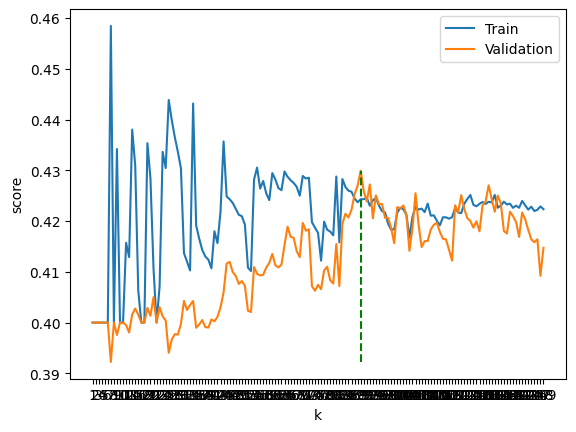

In [519]:
plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()

In [56]:
knn_18 = TunedThresholdClassifierCV(KNeighborsClassifier(n_neighbors=18))
knn_18.fit(X_train_t, y_train)
knn_18.best_threshold_

np.float64(0.28619528619528617)

Text(0.5, 1.0, 'Confusion Matrix')

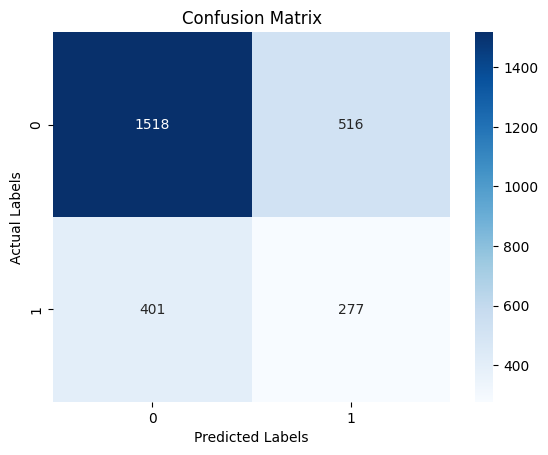

In [57]:
sns.heatmap(confusion_matrix(y_val, knn_18.predict(X_val_t)), fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_val),
                    yticklabels=np.unique(y_val), annot=True)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

In [47]:
X_train_t

,RECENCY_STATUS_96NK_E,RECENCY_STATUS_96NK_F,RECENCY_STATUS_96NK_L,RECENCY_STATUS_96NK_N,RECENCY_STATUS_96NK_S,URBANICITY_R,URBANICITY_S,URBANICITY_T,URBANICITY_U,CARD_PROM_12,CHILDREN,DONOR_AGE,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_GIFT_COUNT,LIFETIME_MIN_GIFT_AMT,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,WEALTH_RATING,LIFETIME_AVG_GIFT_AMT
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
81073,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,0.500,-0.385,0.500,0.000,0.000,-0.500,-0.200,0.286,-0.257,-0.369,-0.338,1.000,-0.500,0.000,0.083,0.474,0.136,0.192,0.000,-0.096,-0.045,-0.500,1.000,0.094,1.000,0.572,0.000,0.000,0.280,-0.306
180383,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,-1.000,-0.885,0.000,-1.000,-0.667,-0.500,0.600,0.000,0.227,0.139,0.394,-0.250,0.500,0.000,0.000,-0.053,-0.545,-0.038,0.000,-0.182,-0.045,-0.250,0.000,-0.322,-0.500,-0.386,1.000,1.000,-0.200,-0.445
30137,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,-1.000,0.500,0.192,-0.500,-1.000,-0.333,0.500,-0.700,2.143,0.360,0.300,-0.690,-0.500,0.000,0.000,0.417,-0.947,1.364,0.346,-1.000,0.646,0.864,0.600,0.000,1.288,-1.000,0.228,0.000,-1.000,-0.120,1.269
31405,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,-3.000,0.000,-0.008,-0.500,-1.000,-0.667,0.000,-0.400,0.000,-0.251,-0.230,-0.296,-0.750,-1.000,0.000,-0.083,0.316,0.045,0.038,0.000,0.124,-0.136,-0.500,2.000,0.983,0.000,0.062,0.000,0.000,-0.360,-0.476
175790,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-2.000,1.000,0.500,-0.500,-1.000,-0.667,0.000,-0.400,0.714,0.005,-0.434,-0.310,2.000,-1.000,0.000,1.917,-1.316,2.227,-0.192,-1.000,0.675,-0.045,-0.150,0.000,-0.382,-0.500,-0.386,0.000,0.000,0.120,-0.003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81061,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-1.000,0.000,0.269,-0.500,0.000,-0.667,-0.100,0.400,-0.143,-0.257,-0.509,0.141,-0.500,0.600,0.000,0.917,-0.579,0.818,0.231,0.000,-0.242,0.227,-0.200,1.000,0.094,0.000,-0.117,1.000,0.000,-0.600,-0.149
122921,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-1.000,-0.592,0.000,0.000,0.000,1.000,-0.500,0.714,-0.282,0.220,-0.507,0.750,0.500,0.000,-0.083,0.947,-0.500,-0.231,0.000,-0.013,0.591,0.300,2.000,0.983,0.000,0.441,0.000,0.000,0.240,0.833
98650,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-2.000,0.000,0.154,-0.500,-1.000,0.333,0.600,-0.700,2.286,-0.311,-0.289,-0.634,0.500,-1.000,0.000,-0.417,0.368,0.318,-1.462,-1.000,0.200,-0.955,0.700,-1.000,-0.858,-1.000,0.000,0.000,0.000,-0.120,1.415


# No NaN

In [58]:
data_no_nan = data.dropna()

In [59]:
len(data_no_nan) / len(data) *100

17.293510324483776

In [66]:
X_no_nan = data_no_nan.drop('TARGET_B', axis=1)
y_no_nan = data_no_nan['TARGET_B']

In [67]:
X_train_no_nan, X_val_no_nan, y_train_no_nan, y_val_no_nan = train_test_split(X_no_nan, y_no_nan, test_size=0.2, shuffle=True, stratify=y_no_nan, random_state=42)

In [68]:
pipe = clone(pipe)
pipe.fit(X_train_no_nan, y_train_no_nan)

c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,numerical_cols,Index(['CARD_... dtype='str')
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thres

In [69]:
pred_train = pipe.predict(X_train)

In [70]:
pred_val = pipe.predict(X_val)

In [71]:
f1_score(y_train, pred_train)

0.4010152284263959

In [72]:
f1_score(y_val, pred_val)

0.40524781341107874

In [73]:
pipe['model'].best_threshold_

np.float64(0.1707070707070707)

Text(0.5, 1.0, 'Confusion Matrix')

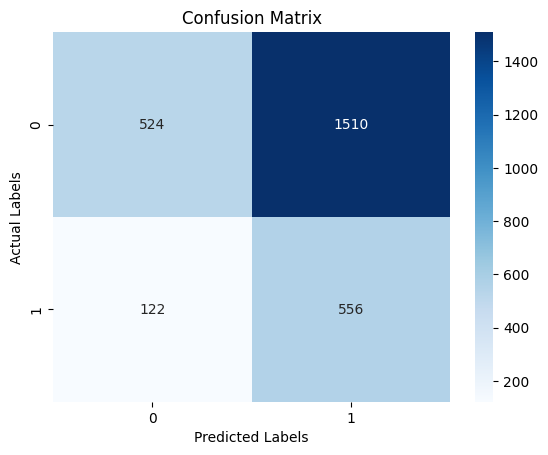

In [74]:
sns.heatmap(confusion_matrix(y_val, pred_val), fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_val),
                    yticklabels=np.unique(y_val), annot=True)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

In [ ]:
print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.82      0.18      0.30      2034
           1       0.26      0.88      0.41       678

    accuracy                           0.36      2712
   macro avg       0.54      0.53      0.35      2712
weighted avg       0.68      0.36      0.33      2712



In [62]:
X_no_nan

,CARD_PROM_12,CHILDREN,DONOR_AGE,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,WEALTH_RATING
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
171942,6.000,3.000,40.000,2.000,4.000,5.000,5.000,18.000,93.000,14.000,10.000,4.000,45.000,824.000,221.000,55.000,15.000,15.000,13.000,0.000,29.000,39.000,30.000,55.000,0.000,8428.000,9.000,6.200,1.000,0.091,5.000,0.238,0.000,1.000
37885,6.000,4.000,69.000,2.000,2.000,6.000,20.000,18.000,105.000,7.000,20.000,5.000,46.000,520.000,217.000,182.037,16.000,16.000,15.000,0.000,4.000,25.000,0.000,57.000,0.000,7811.000,20.000,18.750,2.000,0.182,4.000,0.182,0.000,1.000
3160,6.000,2.000,87.000,3.000,2.000,4.000,25.000,19.000,98.000,7.000,25.000,5.000,66.000,1232.000,451.000,57.000,16.000,18.000,30.000,0.000,27.000,12.000,58.000,66.000,0.000,23222.000,15.000,17.330,2.000,0.250,3.000,0.158,0.000,7.000
136572,6.000,3.000,34.000,2.000,1.000,5.000,30.000,16.000,76.000,4.000,30.000,10.000,42.000,1295.000,459.000,68.000,19.000,19.000,13.000,0.000,35.000,14.000,44.000,60.000,0.000,23634.000,20.000,25.000,1.000,0.111,2.000,0.100,0.000,7.000
112521,4.000,2.000,48.000,10.000,2.000,5.000,29.000,22.000,442.000,21.000,29.000,5.000,57.000,704.000,222.000,68.000,25.000,25.000,9.000,0.000,58.000,24.000,52.000,50.000,1.000,18592.000,26.000,25.140,5.000,0.455,7.000,0.368,1.000,8.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189848,11.000,1.000,79.000,11.000,3.000,1.000,12.000,31.000,292.000,30.000,12.000,4.000,83.000,885.000,264.000,87.000,4.000,12.000,27.000,0.000,35.000,12.000,69.000,74.000,1.000,18769.000,10.000,10.000,5.000,0.500,10.000,0.476,0.000,5.000
63865,5.000,4.000,62.000,12.000,1.000,2.000,12.000,29.000,106.000,19.000,12.000,2.000,70.000,448.000,239.000,128.000,18.000,18.000,12.000,0.000,32.000,23.000,39.000,79.000,1.000,11284.000,12.000,12.000,1.000,0.143,1.000,0.059,0.000,1.000
176252,6.000,4.000,86.000,14.000,2.000,2.000,15.000,28.000,228.000,22.000,15.000,3.000,73.000,716.000,371.000,105.000,22.000,22.000,13.000,2.000,65.000,22.000,44.000,85.000,1.000,15858.000,13.600,14.000,5.000,0.455,8.000,0.381,1.000,6.000


In [ ]:
result_df = run_parameter_search(grid=param_grid, cv=skf_test, X=X_no_nan, y=y_no_nan, model=pipe, metrics=['f1', 'accuracy',
                                    'precision', 'recall'])
result_df

## Ignore for now

k_list = np.arange(1, 20)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in k_list:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_no_nan, y_train_no_nan)
    train_pred = knn_model.predict(X_train_no_nan)
    val_pred = knn_model.predict(X_val_t)
    scores_train.append(f1_score(y_train_no_nan, train_pred))
    scores_val.append(f1_score(y_val_no_nan, val_pred))
    if(f1_score(y_val_no_nan, val_pred)>high_score):
        high_score = f1_score(y_val_no_nan, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()